<a href="https://colab.research.google.com/github/LeviJunior21/ProcessamentoDeLinguagemNatural/blob/master/Word2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas
import requests
from bs4 import BeautifulSoup
import pandas as pd
import unicodedata
import nltk
from nltk.tokenize import word_tokenize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Importando dados do corpus a ser utilizado no treino

In [ ]:
url = 'https://drive.google.com/uc?id=1tEWHdL7AIycQkkb5MlRINhaJAwTL2f2-'
df = pandas.read_csv(url)
df.head()

text = " ".join(df['text'].astype(str))
text = text.lower()[0:150000]

language = "portuguese"
limiar_stop_words = 0

# Tratando o texto

Removendo palavras pequenas de mais e grande de mais do corpus.

In [ ]:
def process_corpus(corpus):
    words = nltk.word_tokenize(corpus, language=language)
    return " ".join([
        word for word in words
        if word.isalpha() and (len(word) > 2 and len(word) < 15)
    ])

text = process_corpus(text)

In [ ]:
def frequent_word_subsample(word_counts):
    total_words = word_counts["Ocorrências"].sum()
    for index, row in word_counts.iterrows():
        f = 1 - np.sqrt(row["Ocorrências"] / total_words)
        print(row["Palavra"], f)

# Descobrindo e removendo as StopWords

Essa etapa é importante porque o modelo pode aprender que palavras sem relevancia estão muito relacionadas a outras palavras de interesse. Palavras como preposições, conjunções, ... são removidas do nosso texto.

Palavras que ocorrem frequentemente tem pouca relevância e palavras que ocorrem raramente tem muita relevância.

Palavras que ocorrem bastante são as prováveis stopwords.

In [ ]:
words = text.split(" ")

stopwords_pt = nltk.corpus.stopwords.words(language)
words = [word for word in words if word not in stopwords_pt]

def remove_acentuacao(palavra):
    nfkd = unicodedata.normalize('NFKD', palavra)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

words = [remove_acentuacao(word) for word in words]

In [ ]:
df = pd.DataFrame(words, columns=["Palavra"])
word_counts = df["Palavra"].value_counts().reset_index()
word_counts.columns = ["Palavra", "Ocorrências"]
word_counts["Ranking"] = range(1, len(word_counts) + 1)
print(word_counts)

stopwords_text = word_counts[:limiar_stop_words]
stopwords_text = stopwords_text["Palavra"].tolist()

text = " ".join([word for word in words if word not in stopwords_text])

          Palavra  Ocorrências  Ranking
0         justica          142        1
1        tribunal          132        2
2             art          123        3
3         recurso          115        4
4             lei          108        5
...           ...          ...      ...
3084       deseja            1     3085
3085       furtar            1     3086
3086   demonstram            1     3087
3087  constatadas            1     3088
3088        reque            1     3089

[3089 rows x 3 columns]


# Word2Vec

In [ ]:
class Word2Vec:
    def __init__(self, text, window=6, min_count=3, neurons=10, epochs=1, loss = 0., learning_rate = 0.1):
        self.text = text.split(" ")
        self.window = window
        self.min_count = min_count
        self.model = None
        self.neurons = neurons
        self.loss = 0.01
        self.learning_rate = learning_rate

        np.random.seed(10)
        self.W1 = np.random.rand(len(set(self.text)), neurons)
        self.W2 = np.random.rand(neurons, len(set(self.text)))

        self.unique_words = self.encoding()
        self.window_of_words = []
        self.one_hot_encoding()

        self.train(epochs)


    """
    Transforma o texto em um set de palavras unicas, e para cada palavra criamos representações vetoriais em forma de One-Hot-Encoding.

    Por exemplo, para a frase "bom dia amigo":
    bom:    [1, 0, 0]
    dia:    [0, 1, 0]
    amigo:  [0, 0, 1]

    returns:
    Retorna um dicionário do one-hot-encoding para cada palavra.
    """
    def encoding(self):
        unique_words = list(enumerate(dict.fromkeys(self.text)))
        hash_unique_words = {}

        for key, val in unique_words:
            vetor = [0] * len(set(self.text))
            vetor[key] = 1
            hash_unique_words[val] = vetor

        return hash_unique_words


    """
    - Para cada palavra do texto navega-se numa janela de palavras, onde nessa janela há a palavra central e os alvos que são as demais palavras da janela (exceto a palavra de contexto).
    A partir disso criamos uma tupla onde no primeiro indice temos o one-hot-encoding da palavra de contexto e no segundo elemento temos uma lista de one-hot-encoding das palavras alvos para a palavra de contexto.

    - Por exemplo, para a frase: "i like playing football with my friends"
    A partir do One-Hot-Encoding para as palavras únicas
    i:          [1, 0, 0, 0, 0, 0, 0]
    like:       [0, 1, 0, 0, 0, 0, 0]
    playing:    [0, 0, 1, 0, 0, 0, 0]
    football:   [0, 0, 0, 1, 0, 0, 0]
    with:       [0, 0, 0, 0, 1, 0, 0]
    my:         [0, 0, 0, 0, 0, 1, 0]
    friends:    [0, 0, 0, 0, 0, 0, 1]

    - Teremos uma janela de palavras:
    Considere o tamanho mínimo de 3 e máximo de 5 palavras para a janela.

    iteração 0: [(i) like playing] football with my friends
    iteração 1: [i (like) playing football] with my friends
    iteração 2: [i like (playing) football with] my friends
    iteração 3: i [like playing (football) with my] friends
    iteração 4: i like [playing football (with) my friends]
    iteração 5: i like playing [football with (my) friends]
    iteração 6: i like playing football [with my (friends)]

    - Para a iteração 0:
        A palavra central é "i"
        As palavras alvos são "like" e "playing"

        i -> like, playing
        [1, 0, 0, 0, 0, 0, 0] -> [0, 1, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0]

    - Para a iteração 1:
        A palavra central é "like"
        As palavras alvos são "i", "playing" e "football"

        like -> i, playing, football
        [0, 1, 0, 0, 0, 0, 0] -> [1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0],
                                 [0, 0, 0, 1, 0, 0, 0]

    - Para a iteração 2:
        A palavra central é "playing"
        As palavras alvos são "i", "like", "football" e "with"

        playing -> i, like, football, with
        [0, 0, 1, 0, 0, 0, 0] -> [1, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0],
                                 [0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0]

    - Para a iteração 3:
        A palavra central é "football"
        As palavras alvos são "like", "playing", "with" e "my"

        football -> like, playing, with, my
        [0, 0, 0, 1, 0, 0, 0] -> [0, 1, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0],
                                 [0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0]

    - Para a iteração 4:
        A palavra central é "with"
        As palavras alvos são "playing", "football", "my" e "friends"

        with -> playing, football, my, friends
        [0, 0, 0, 0, 1, 0, 0] -> [0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0],
                                 [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 1]

    - Para a iteração 5:
        A palavra central é "my"
        As palavras alvos são "football", "with" e "friends"

        with -> football, with, friends
        [0, 0, 0, 0, 0, 1, 0] -> [0, 0, 0, 1, 0, 0, 0],
                                 [0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1]

    - Para a iteração 6:
        A palavra central é "friends"
        As palavras alvos são "with" e "my"

        friends -> with, my
        [0, 0, 0, 0, 0, 0, 1] -> [0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0]

    Ele pega cada um desses resultados e transforma uma lista de tuplas, onde cada tupla tem o One-Hot-Encoding da palavra central na primeira posição e uma lista de One-Hot-Encoding das palavras alvos na segunda posição.

    Por exemplo:
    [
    ([1, 0, 0, 0, 0, 0, 0], [[0, 1, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0]],
    ...,
    ([0, 0, 0, 0, 0, 0, 1], [[0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0]]
    ]

    returns:
        Retorna uma lista de tuplas, onde cada tupla tem o One-Hot-Encoding da palavra central na primeira posição e uma lista de One-Hot-Encoding das palavras alvos na segunda posição.
    """
    def one_hot_encoding(self):
        words = list(enumerate(self.text))

        for i in range(len(words)):
            if (i >= self.min_count):

                if (i < self.window):
                    window_of_words = words[:i + 1]

                    center_index = i - self.min_count
                    center_word = self.unique_words[self.text[center_index]]

                    target_words = self.give_target_words(
                        window_of_words,
                        center_index,
                        words
                    )

                    self.window_of_words.append(
                        (np.array(center_word), np.array(target_words))
                    )

                else:
                    window_of_words = (words[(i - self.window + 1):i + 1])

                    center_index = i - self.min_count
                    center_word = self.unique_words[self.text[center_index]]

                    target_words = self.give_target_words(
                        window_of_words,
                        center_index,
                        words
                    )

                    self.window_of_words.append(
                        (np.array(center_word), np.array(target_words))
                    )

        for i in range(len(words) - self.min_count - 1, len(words) - 1):
            window_of_words = words[i - 1:]

            center_index = i + 1
            center_word = self.unique_words[self.text[center_index]]

            target_words = self.give_target_words(
                window_of_words,
                center_index,
                words
            )

            self.window_of_words.append(
                (np.array(center_word), np.array(target_words))
            )


    """
    - A partir da janela de palavras em forma de texto e da o indice da palavra central, mapeia cada palavra alvo em seus respectivos One-Hot-Encoding.

    returns:
        Retorna o One-Hot-Encoding das palavras alvo da janela deslizante.
    """
    def give_target_words(self, window_of_words, center_index, words):
        target_words = []

        for j, word in window_of_words:
            if j != center_index and self.unique_words[self.text[center_index]] != self.unique_words[word]:
                target_word = self.unique_words[word]
                target_words.append(target_word)

        return target_words


    """
    Função de ativação Softmax.
    """
    def softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum(axis=0)


    """
    Feedforward propagation para cada palavra central e palavra alvo.
    """
    def feed_forward(self, center, target, w1, w2, loss):
        h = np.dot(w1.T, center)
        u = np.dot(w2.T, h)
        y_pred = self.softmax(u)

        e = np.array([y_pred.T - label for label in target])
        dW2 = np.outer(h, np.sum(e, axis=0))
        dW1 = np.outer(center, np.dot(w2, np.sum(e, axis=0)))

        new_W1 = w1 - self.learning_rate * dW1
        new_W2 = w2 - self.learning_rate * dW2

        loss += -np.sum([u[label == 1] for label in target]) + len(target) * np.log(np.sum(np.exp(u)))

        return new_W1, new_W2, loss


    """
    - Treina o modelo através do método SkipGram, onde a partir de uma palavra central, tenta prever as palavras alvo.
    """
    def train(self, epochs):
        print("Iniciando treino")

        for epoch in range(epochs):
            loss = 0

            for i, (center, target) in enumerate(self.window_of_words):
                self.W1, self.W2, loss = self.feed_forward(
                    center, target, self.W1, self.W2, loss
                )

            print("epoch {}: loss = {}\n".format(epoch + 1, loss))


    """
    - Retorna a matriz de Embeddings da rede neural.
    Os embeddibgs são o conhecimento da rede neural. Neste caso temos o conhecimento da representação de cada palavra na primeira matriz de embeddibgs que fica entre a camada de entrada e a camada escondida.

    returns:
        Retorna os embeddings das palavras.
    """
    def embeddings(self):
        return self.W1


    """
    - Calcula a similaridade cosseno entre uma palavra de interesse para as demais palavras do texto.
    Na matriz de embedding, recuperamos o embedding da palavra de interesse e calculamos a similaridade cosseno para os embeddings de cada uma das demais palavras e retornamos uma lista de palavras similares ordenadas pela maior probabilidade, onde na primeira posição temos a palavra, na segunda posição temos o nível de similaridade e na terceira posição temos o embedding da palavra.

    returns:
        Retorna uma lista de palavras similares ordenadas da maior probabilidade a menor probabilidade.
    """
    def similarity_cosine(self, word, number_words):
        word_index = self.unique_words[word].index(1)
        embeddings = self.embeddings()
        word_embedding = embeddings[word_index]

        similar = []
        for i in range(len(embeddings)):
            palavra, emb = list(self.unique_words.keys())[i], embeddings[i]

            dot_product = np.dot(word_embedding, emb)
            aNorm = np.linalg.norm(word_embedding)
            bNorm = np.linalg.norm(emb)

            cosine_similarity = dot_product / (aNorm * bNorm)
            similar.append((palavra, cosine_similarity, emb))

        return sorted(similar, key=lambda x: x[1], reverse=True)[:number_words]


    """
    - Para cada Embedding reduz-se a sua dimensionalidade para apenas 2 simenões e plotamos as palavras no gráfico a partir dos seus embeddings em 2 dimensões.
    """
    def plot(self, target, size):
        embeddings = self.similarity_cosine(target, size)
        reducer = PCA(n_components=2)

        reducer_vectors = reducer.fit_transform([emb for _,_,emb in embeddings])
        limited_words = [word for word,_,_ in embeddings]

        plt.figure(figsize=(12,8))
        for i, word in enumerate(limited_words):
            x, y = reducer_vectors[i]
            plt.scatter(x, y)
            plt.text(x, y, word, fontsize=9)

        plt.title(f'Top {size} Embeddings similar a palavra {target} via PCA')
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid()
        plt.show()


    def most_similar(self, positive, negative):
        emb = np.array([0] * self.neurons)

        for word in set(positive):
            word_index = self.unique_words[word].index(1)
            embeddings = self.embeddings()
            emb = np.sum(emb, np.array(embeddings[word_index]))

        for word in set(negative):
            word_index = self.unique_words[word].index(1)
            embeddings = self.embeddings()
            emb -= np.array(embeddings[word_index])


        similarity_degree = []
        for i in range(len(self.unique_words)):
            emb_ = self.unique_words[i]
            similarity = self.similarity_cosine(self.unique_words[i])
            similarity_degree.append(similarity)

        return sorted(similarity_degree, key=lambda x: x[1], reverse=True)[0]


    def positional_encoding(self, num_tokens, dimensions, n):
        positional_matrix = np.zeros((num_tokens, dimensions))

        for row in range(num_tokens):
            for col in range(dimensions - 1):
                denominator = np.power(n, col/dimensions)

                if col % 2 == 0:
                    positional_matrix[row, col] = np.sin(row/denominator)
                else:
                    positional_matrix[row, col + 1] = np.cos(row/denominator)

        fig = plt.matshow(positional_matrix)
        plt.gcf().colorbar(fig)
        plt.title("Positional Encoding")
        plt.xlabel("Número de Tokens")
        plt.ylabel("Número de dimensões")
        plt.show()

        for i in range(num_tokens):
            sum = self.embeddings_layer[i] + positional_matrix[i]
            self.embeddings_layer[i] = sum

# Testes

In [ ]:
text_test = "a b c d a e f b a e f g v"
model_test = Word2Vec(text_test, 5, 2, 3, 1)

"""
'a': [1, 0, 0, 0, 0, 0, 0, 0],
'b': [0, 1, 0, 0, 0, 0, 0, 0],
'c': [0, 0, 1, 0, 0, 0, 0, 0],
'd': [0, 0, 0, 1, 0, 0, 0, 0],
'e': [0, 0, 0, 0, 1, 0, 0, 0],
'f': [0, 0, 0, 0, 0, 1, 0, 0],
'g': [0, 0, 0, 0, 0, 0, 1, 0],
'v': [0, 0, 0, 0, 0, 0, 0, 1]
"""

window = model_test.window_of_words
teste = [
    (   np.array([1, 0, 0, 0, 0, 0, 0, 0]), # (.a b c) d a e f b a e f g v
        np.array([
            [0, 1, 0, 0, 0, 0, 0, 0], # b
            [0, 0, 1, 0, 0, 0, 0, 0]  # c
        ])
    ),
    (   np.array([0, 1, 0, 0, 0, 0, 0, 0]), # (a .b c d) a e f b a e f g v
         np.array([
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 0, 1, 0, 0, 0, 0, 0], # c
            [0, 0, 0, 1, 0, 0, 0, 0]  # d
        ])
    ),
    (   np.array([0, 0, 1, 0, 0, 0, 0, 0]), # (a b .c d a) e f b a e f g v
        np.array([
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 1, 0, 0, 0, 0, 0, 0], # b
            [0, 0, 0, 1, 0, 0, 0, 0], # d
            [1, 0, 0, 0, 0, 0, 0, 0]  # a
        ])
    ),
    (   np.array([0, 0, 0, 1, 0, 0, 0, 0]), # a (b c .d a e) f b a e f g v
        np.array([
            [0, 1, 0, 0, 0, 0, 0, 0], # b
            [0, 0, 1, 0, 0, 0, 0, 0], # c
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 0, 0, 0, 1, 0, 0, 0]  # e
        ])
    ),
    (   np.array([1, 0, 0, 0, 0, 0, 0, 0]), # a b (c d .a e f) b a e f g v
        np.array([
            [0, 0, 1, 0, 0, 0, 0, 0], # c
            [0, 0, 0, 1, 0, 0, 0, 0], # d
            [0, 0, 0, 0, 1, 0, 0, 0], # e
            [0, 0, 0, 0, 0, 1, 0, 0]  # f
        ])
    ),
    (   np.array([0, 0, 0, 0, 1, 0, 0, 0]), # a b c (d a .e f b) a e f g v
        np.array([
            [0, 0, 0, 1, 0, 0, 0, 0], # d
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 0, 0, 0, 0, 1, 0, 0], # f
            [0, 1, 0, 0, 0, 0, 0, 0]  # b
        ])
    ),
    (   np.array([0, 0, 0, 0, 0, 1, 0, 0]), # a b c d (a e .f b a) e f g v
        np.array([
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 0, 0, 0, 1, 0, 0, 0], # e
            [0, 1, 0, 0, 0, 0, 0, 0], # b
            [1, 0, 0, 0, 0, 0, 0, 0]  # a
        ])
    ),
    (   np.array([0, 1, 0, 0, 0, 0, 0, 0]), # a b c d a (e f .b a e) f g v
        np.array([
            [0, 0, 0, 0, 1, 0, 0, 0], # e
            [0, 0, 0, 0, 0, 1, 0, 0], # f
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 0, 0, 0, 1, 0, 0, 0]  # e
        ])
    ),
    (   np.array([1, 0, 0, 0, 0, 0, 0, 0]), # a b c d a e (f b .a e f) g v
        np.array([
            [0, 0, 0, 0, 0, 1, 0, 0], # f
            [0, 1, 0, 0, 0, 0, 0, 0], # b
            [0, 0, 0, 0, 1, 0, 0, 0], # e
            [0, 0, 0, 0, 0, 1, 0, 0]  # f
        ])
    ),
    (   np.array([0, 0, 0, 0, 1, 0, 0, 0]), # a b c d a e f (b a .e f g) v
        np.array([
            [0, 1, 0, 0, 0, 0, 0, 0], # b
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 0, 0, 0, 0, 1, 0, 0], # f
            [0, 0, 0, 0, 0, 0, 1, 0]  # g
        ])
    ),
    (   np.array([0, 0, 0, 0, 0, 1, 0, 0]), # a b c d a e f b (a e .f g v)
        np.array([
            [1, 0, 0, 0, 0, 0, 0, 0], # a
            [0, 0, 0, 0, 1, 0, 0, 0], # e
            [0, 0, 0, 0, 0, 0, 1, 0], # g
            [0, 0, 0, 0, 0, 0, 0, 1]  # v
        ])
    ),
    (   np.array([0, 0, 0, 0, 0, 0, 1, 0]), # a b c d a e f b a (e f .g v)
        np.array([
            [0, 0, 0, 0, 1, 0, 0, 0], # e
            [0, 0, 0, 0, 0, 1, 0, 0], # f
            [0, 0, 0, 0, 0, 0, 0, 1]  # v
        ])
    ),
    (   np.array([0, 0, 0, 0, 0, 0, 0, 1]), # a b c d a e f b a e (f g .v)
        np.array([
            [0, 0, 0, 0, 0, 1, 0, 0], # f
            [0, 0, 0, 0, 0, 0, 1, 0]  # g
        ])
    )
]

Iniciando treino
epoch 1: loss = 94.39897017125851



In [ ]:
# Usando o exemplo do slide da aula de Word2Vec para verificar se bate
text_test2 = "i like playing football with my friends"
model_test2 = Word2Vec(text_test2, 5, 2, 1)

teste = [
    (   np.array([1, 0, 0, 0, 0, 0, 0]),
        np.array([
            [0, 1, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0]
        ])
    ),
    (   np.array([0, 1, 0, 0, 0, 0, 0]),
        np.array([
            [1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0]
        ])
    ),
    (   np.array([0, 0, 1, 0, 0, 0, 0]),
        np.array([
            [1, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0]
        ])
    ),
    (   np.array([0, 0, 0, 1, 0, 0, 0]),
        np.array([
            [0, 1, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 1, 0]
        ]),
    ),
    (   np.array([0, 0, 0, 0, 1, 0, 0]),
        np.array([
            [0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 1]
        ])
    ),
    (   np.array([0, 0, 0, 0, 0, 1, 0]),
        np.array([
            [0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1]
        ])
    ),
    (   np.array([0, 0, 0, 0, 0, 0, 1]),
        np.array([
            [0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 1, 0]
        ])
    )
]

Iniciando treino
epoch 1: loss = 43.71156547662864



# Ambiente

Inicializando o ambiente, fazendo algumas etapas iniciais, como o One-Hot-Encoding para preparar os dados para o treinamento.

In [ ]:
module = Word2Vec(text, window=6, min_count=3, neurons=300, epochs=10)

Iniciando treino
epoch 1: loss = 775716.1596055899

epoch 2: loss = 607475.7178540837

epoch 3: loss = 531686.6938463805

epoch 4: loss = 489150.29262669064

epoch 5: loss = 454124.9496545683

epoch 6: loss = 425097.8006770905

epoch 7: loss = 395564.45934573316

epoch 8: loss = 369463.7149402693

epoch 9: loss = 350997.9693105813

epoch 10: loss = 340239.4506490075



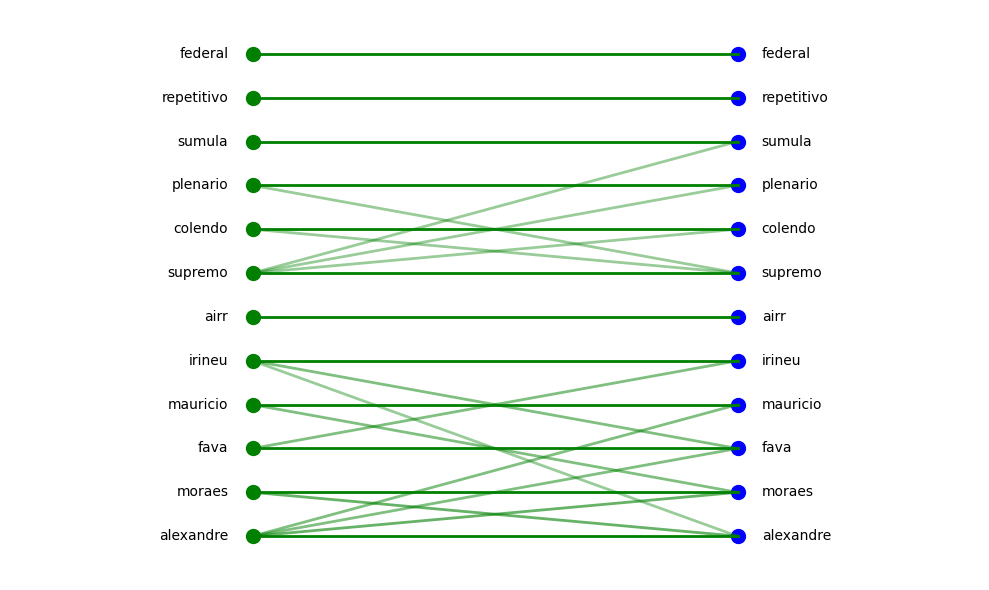

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import random

#words_sorted = random.sample(text.split(" "), 2)
words_sorted = ["alexandre", "supremo"]
num_similars = 6

compare_words = {
    word: [(i,w)  for i,w,_, in module.similarity_cosine(word, num_similars)]
    for word in words_sorted
}

words_left = []
for word in compare_words.keys():
    for i, _ in compare_words[word]:
        words_left.append(i)

words_left = list(enumerate(dict.fromkeys(words_left)))
words_right = words_left

similars = {}

for i in range(len(words_left)):
    word = words_left[i][1]
    similar = module.similarity_cosine(word, 4)

    for w, s, _ in similar:
        if word not in similars:
            similars[word] = {
                "source": i,
                "target": []
            }

        if w in [item[1] for item in words_left]:
            w_index = next(idx for idx, val in words_left if val == w)
            similars[word]["target"].append((w_index, s))

list_ = list(enumerate(dict.fromkeys(similars)))
connections = []
for word in list_:
    for target, w in similars[word[1]]["target"]:
        connections.append([
            similars[word[1]]["source"],
            target,
            round(w, 1)
        ])

y_left = np.arange(len(words_left))
y_right = np.arange(len(words_right))

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter([0] * len(y_left), y_left, c="green", s=100, label="Left Words")
ax.scatter([1] * len(y_right), y_right, c="blue", s=100, label="Right Words")

for i, word in words_left:
    ax.text(-0.05, y_left[i], word, ha="right", va="center", fontsize=10)

for i, word in words_right:
    ax.text(1.05, y_right[i], word, ha="left", va="center", fontsize=10)

for left, right, weight in connections:
    ax.plot([0, 1], [y_left[left], y_right[right]], "green", alpha=weight, linewidth=2)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-1, max(len(words_left), len(words_right)))
ax.axis("off")

plt.tight_layout()
plt.show()

[('alexandre', 1.0), ('moraes', 0.6367150704647319), ('fava', 0.4588505129635058), ('mauricio', 0.45120623324750814), ('irineu', 0.44164095559732675), ('airr', 0.4026409534461495), ('moreira', 0.39792237540001946), ('alves', 0.3946763939928156), ('humberto', 0.39307859003183104), ('grace', 0.3899735530592706)]


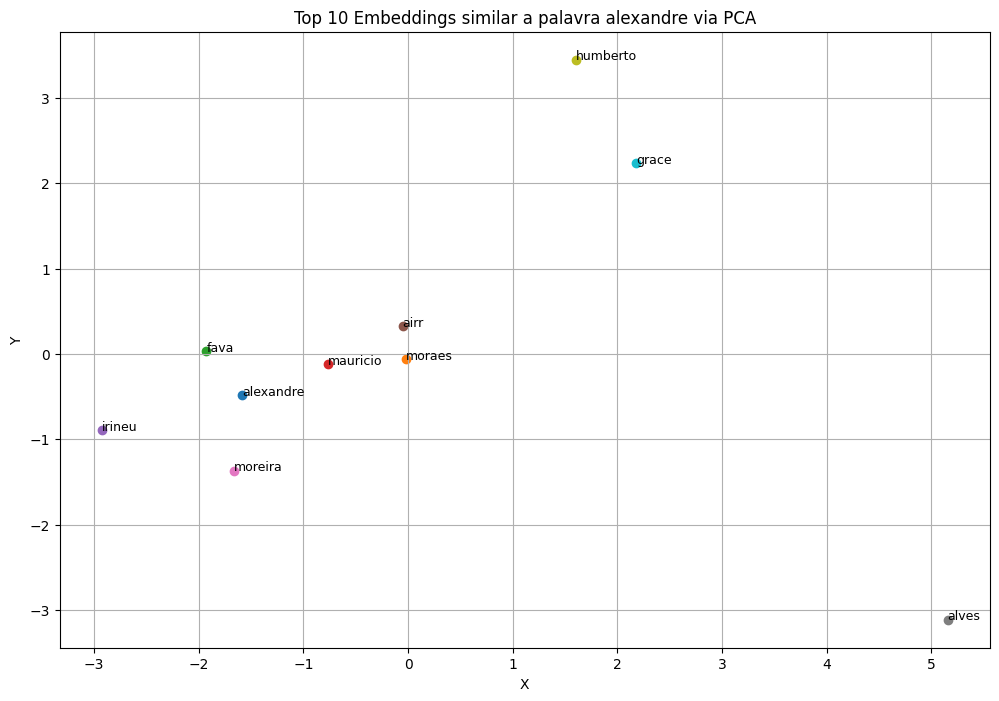

In [ ]:
word = "alexandre"
length = 10
print([(x, y) for x, y,_ in module.similarity_cosine(word, length)])
module.plot(word, length)

[('supremo', 1.0000000000000002), ('colendo', 0.42317461137628526), ('plenario', 0.3686309220542995), ('sumula', 0.35793042829836164), ('repetitivo', 0.33546544284313523), ('federal', 0.32985529970564353), ('nunc', 0.3269049949386127), ('estadual', 0.3248995198588446), ('ofensa', 0.3229692398132476), ('deste', 0.32258100657293687)]


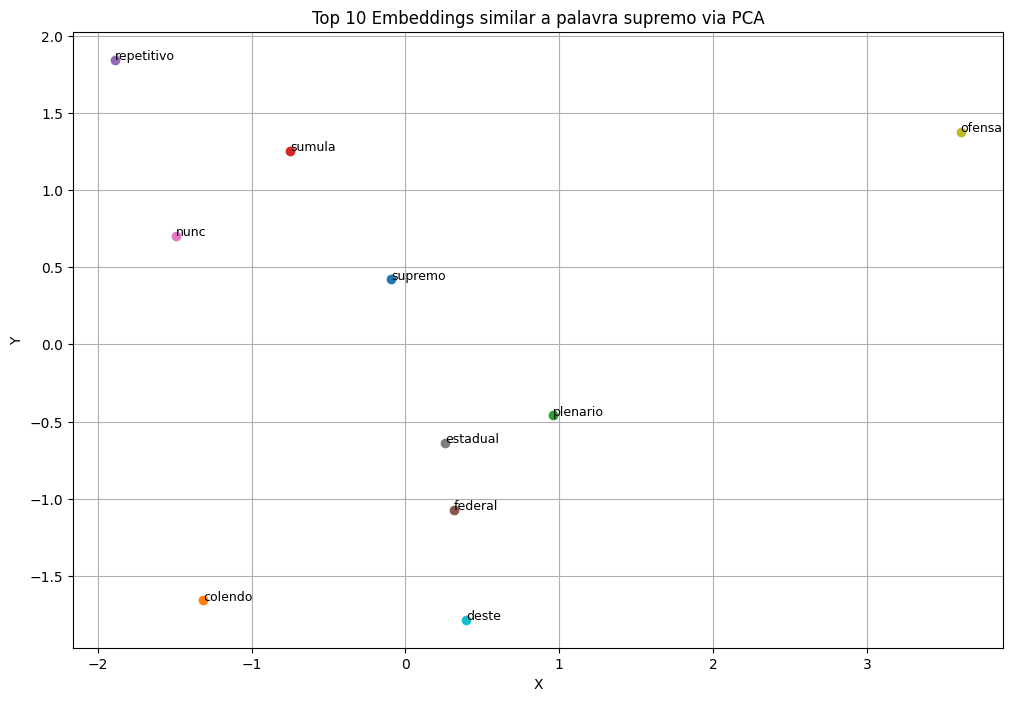

In [ ]:
word = "supremo"
length = 10
print([(x, y) for x, y,_ in module.similarity_cosine(word, length)])
module.plot(word, length)

# Word2Vec com amostras negativas

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Flatten, Embedding, Reshape, Dot, Activation, Lambda
import keras
from keras import activations

In [ ]:
class Word2VecNegativeSample:
    def __init__(self, text, window, min_count, negative_samples):
        self.text = text.split(" ")
        self.window = window
        self.min_count = min_count
        self.negative_samples = negative_samples
        self.model = None

        self.unique_words = self.encoding()
        self.window_of_words = []
        self.one_hot_encoding()


    """
    Transforma o texto em um set de palavras unicas, e para cada palavra criamos um id único.

    Por exemplo, para a frase "bom dia amigo":
    bom:    0
    dia:    1
    amigo:  2

    returns:
    Retorna um dicionário do one-hot-encoding para cada palavra.
    """
    def encoding(self):
        unique_words = list(enumerate(dict.fromkeys(self.text)))
        hash_unique_words = {}

        for key, val in unique_words:
            hash_unique_words[val] = key

        return hash_unique_words


    """
    - Para cada palavra do texto navega-se numa janela de palavras, onde nessa janela há a palavra central e os alvos que são as demais palavras da janela (exceto a palavra de contexto).
        - A partir disso criamos amostras positivas.
        Fixada a palavra de contexto, recuperamos o id da palavra de contexto e o id de cada palavra de alvo, essas são as amostras positivas
        E por fim, para cada palavra alvo, teremos uma tupla de tres elementos:

        (id da palavra de contexto, id da palavra alvo, tipo de amostra)

        E colocamos o número 1 no terceiro elemento(tipo de amostra) da tupla para indicar que essa tupla representa um tipo de amostra positiva.

        Para cada amostra positiva, criamos algumas amostras negativas que são para as palavras que estão fora da janela. Ou seja, a palavra de contexto não deseja prever algumas palavras de fora da janela.
        Para isso, sorteamos algumas palavras de fora da janela e para cada palavra não-alvo, criamos uma tupla de três elementos.

        (id da palavra de contexto, id da palavra não-alvo, tipo de amostra)

        E colocamos o número 0 no terceiro elemento(tipo de amostra)  da tupla para indicar que essa tupla representa um tipo de amostra negativa.


    Por exemplo:
    Para a frase "i like playing football with my friends joão and ana"

    Iremos fazer para uma janela deslizante de tamanho mínimo 3 e máximo 5 palavras e duas palavras aleatórias distintas fora da jalena.

    Primeiro iremos criar um id para cada palavra unica.
    i:          0
    like:       1
    playing:    2
    football:   3
    with:       4
    my:         5
    friends:    6
    joão:       7
    and:        8
    ana:        9

    - Para a iteração 0:
        [(i) like playing] football with my friends joão and ana

        A palavra central é "i"
        As palavras alvos são "like" e "playing"

        i -> like, playing
        0 -> 1, 2

        Para a palavra alvo "like":

            - Para amostra positiva (terceiro elemento da tupla é 1):
            (id da palavra de contexto, id da palavra alvo, tipo de amostra: 1)
            0 -> 1: (0,1,1),
            Ou seja uma amostra positiva pois pertence a janela para a palavra central "i" e alvo "like".

            Vamos para as amostras negativas para o par positivo da palavra central "i" e alvo "playing". Como escolhemos 2 amostras negativas para cada par psoitivo ficamos com:

                Sorteando por exemplo, "with" e "and"
                0 -> 4, 8

                Para amostra negativa (terceiro elemento da tupla é 0):
                (id da palavra de contexto, id da palavra alvo, tipo de amostra: 0)
                (0,4,0), ou seja uma amostra negativa porque não pertence a janela para a palavra central "i" e não alvo "with".
                (0,8,0), ou seja uma amostra negativa porque não pertence a janela para a palavra central "i" e não alvo "and".

        Para a palavra alvo "playing":
            - Para amostra positiva (terceiro elemento da tupla é 1):
            (id da palavra de contexto, id da palavra alvo, tipo de amostra: 1)
            0 -> 2: (0,2,1),
            Ou seja uma amostra positiva pois pertence a janela para a palavra central "i" e alvo "playing".

            Vamos para as amostras negativas para o par positivo da palavra central "i" e alvo "playing". Como escolhemos 2 amostras negativas para cada par psoitivo ficamos com:

                Sorteando por exemplo, "football" e "my"
                0 -> 3, 5

                Para amostra negativa (terceiro elemento da tupla é 0):
                (id da palavra de contexto, id da palavra alvo, tipo de amostra: 0)
                (0,3,0), ou seja uma amostra negativa porque não pertence a janela para a palavra central "i" e não alvo "football".
                (0,5,0), ou seja uma amostra negativa porque não pertence a janela para a palavra central "i" e não alvo "my".


    E faremos isso para as demais janelas.
    """
    def one_hot_encoding(self):
        words = list(enumerate(self.text))

        for i in range(len(words)):
            if (i >= self.min_count):

                if (i < self.window):
                    window_of_words = words[:i + 1]

                    center_index = i - self.min_count
                    center_word = self.unique_words[self.text[center_index]]

                    self.give_target_words(
                        window_of_words,
                        center_index,
                        words,
                        center_word,
                        0,
                        i + 1
                    )

                else:
                    window_of_words = (words[(i - self.window + 1):i + 1])

                    center_index = i - self.min_count
                    center_word = self.unique_words[self.text[center_index]]

                    self.give_target_words(
                        window_of_words,
                        center_index,
                        words,
                        center_word,
                        i - self.window + 1,
                        i + 1
                    )

        for i in range(len(words) - self.min_count - 1, len(words) - 1):
            window_of_words = words[i - 1:]

            center_index = i + 1
            center_word = self.unique_words[self.text[center_index]]

            self.give_target_words(
                window_of_words,
                center_index,
                words,
                center_word,
                i - 1,
                len(words)
            )


    def give_target_words(self, window_of_words, center_index, words, center_word, i, n):
        target_words = []

        for j, word in window_of_words:
            vector = self.unique_words[self.text[center_index]]
            if j != center_index and vector != self.unique_words[word]:

                target_word = self.unique_words[word]
                target_words.append(target_word)

                self.window_of_words.append((center_word, target_word, 1))

                self.give_negative_samples(
                    words,
                    center_word,
                    target_words,
                    i,
                    n
                )


    def give_negative_samples(self, words, center_word, target_words, i, n):
        used = []

        k = self.negative_samples
        while True:
            not_target_ = [x for x in range(len(self.text)) if x < i or x >= n]
            pos = random.sample(not_target_, 1)[0]

            not_target = self.unique_words[self.text[pos]]

            all_targets = [center_word] + target_words + used

            if not_target not in all_targets:
                self.window_of_words.append((center_word, not_target, 0))
                used.append(not_target)

                k = k - 1
                if k == 0: break


    def train(self, epochs):
        input_wordcentral, input_wordtarget, labels = [], [], []
        for x, y, z in self.window_of_words:
            input_wordcentral.append(x)
            input_wordtarget.append(y)
            labels.append(z)

        input_wordcentral = np.array(input_wordcentral)
        input_wordtarget = np.array(input_wordtarget)
        labels = np.array(labels)

        vocab_size = len(self.unique_words)

        input_central = Input(shape=(1,))
        word_embed = Embedding(vocab_size, self.window)(input_central)

        input_target = Input(shape=(1,))
        context_embed = Embedding(vocab_size, self.window)(input_target)

        dot_product = Dot(axes=2)([word_embed, context_embed])
        dot_product = Reshape((1,), input_shape=(1,1))(dot_product)

        output = Activation(keras.activations.sigmoid)(dot_product)

        model = Model(
            inputs=[input_central, input_target],
            outputs=output
        )
        model.compile(
            loss=keras.losses.CategoricalCrossentropy(from_logits=True),
            optimizer=keras.optimizers.Adam(),
            metrics=["accuracy"]
        )

        model.summary()

        x_train_central, x_test_central, x_train_target, x_test_target, y_train, y_test = train_test_split(
            input_wordcentral,
            input_wordtarget,
            labels,
            test_size=0.2,
            random_state=42
        )

        model.fit(
            [x_train_central, x_train_target], y_train,
            batch_size=64,
            epochs=epochs,
            validation_data=([x_test_central, x_test_target], y_test)
        )

        self.model = model


    def model(self):
        return self.model


    def embeddings(self):
        word_embeddings = self.model.get_layer(index=2).get_weights()[0]
        return word_embeddings


    def similarity_cosine(self, word, number_words):
        word_index = self.unique_words[word]
        embeddings = self.embeddings()
        word_embedding = embeddings[word_index]

        similar = []
        for i in range(len(embeddings)):
            palavra, emb = list(self.unique_words.keys())[i], embeddings[i]

            dot_product = np.dot(word_embedding, emb)
            aNorm = np.linalg.norm(word_embedding)
            bNorm = np.linalg.norm(emb)

            cosine_similarity = dot_product / (aNorm * bNorm)
            similar.append((palavra, cosine_similarity, emb))

        return sorted(similar, key=lambda x: x[1], reverse=True)[:number_words]


    def plot(self, target, size):
        embeddings = self.similarity_cosine(target, size)
        reducer = PCA(n_components=2)

        reducer_vectors = reducer.fit_transform([emb for _,_,emb in embeddings])
        limited_words = [word for word,_,_ in embeddings]

        plt.figure(figsize=(12,8))
        for i, word in enumerate(limited_words):
            x, y = reducer_vectors[i]
            plt.scatter(x, y)
            plt.text(x, y, word, fontsize=9)

        plt.title(f'Top {size} Embeddings similar a palavra {target} via PCA')
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid()
        plt.show()

# Ambiente

In [ ]:
model3 = Word2VecNegativeSample(text, 10, 3, 5)

# Treinando o Modelo

In [ ]:
model3.train(10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 1)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 1, 10)          │         30,890 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, 1, 10)          │         30,890 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dot (Dot)                 │ (None, 1, 1)           │              0 │ embedding[0][0],       │
│                           │                        │                │ embedding_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1)              │              0 │ dot[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 1)              │              0 │ reshape[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 61,780 (241.33 KB)

 Trainable params: 61,780 (241.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:593: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


8443/8443 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.7505 - loss: 0.0000e+00 - val_accuracy: 0.8318 - val_loss: 0.0000e+00
Epoch 2/10
8443/8443 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8335 - loss: 0.0000e+00 - val_accuracy: 0.8318 - val_loss: 0.0000e+00
Epoch 3/10
8443/8443 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.8334 - loss: 0.0000e+00 - val_accuracy: 0.8318 - val_loss: 0.0000e+00
Epoch 4/10
8443/8443 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8339 - loss: 0.0000e+00 - val_accuracy: 0.8318 - val_loss: 0.0000e+00
Epoch 5/10
8443/8443 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8343 - loss: 0.0000e+00 - val_accuracy: 0.8318 - val_loss: 0.0000e+00
Epoch 6/10
8443/8443 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.8336 - loss: 0.0000e+00 - val_accuracy: 0.8318 - val_loss: 0.0000e+00
Epoch 7/10
8443/8443 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8341 - loss: 0.0000e+00 - val_accuracy: 0.8318 - val_loss: 0.0000e+00
Epoch 8/10
8443/8443 ━━━━━━━━━━━━━━━━━

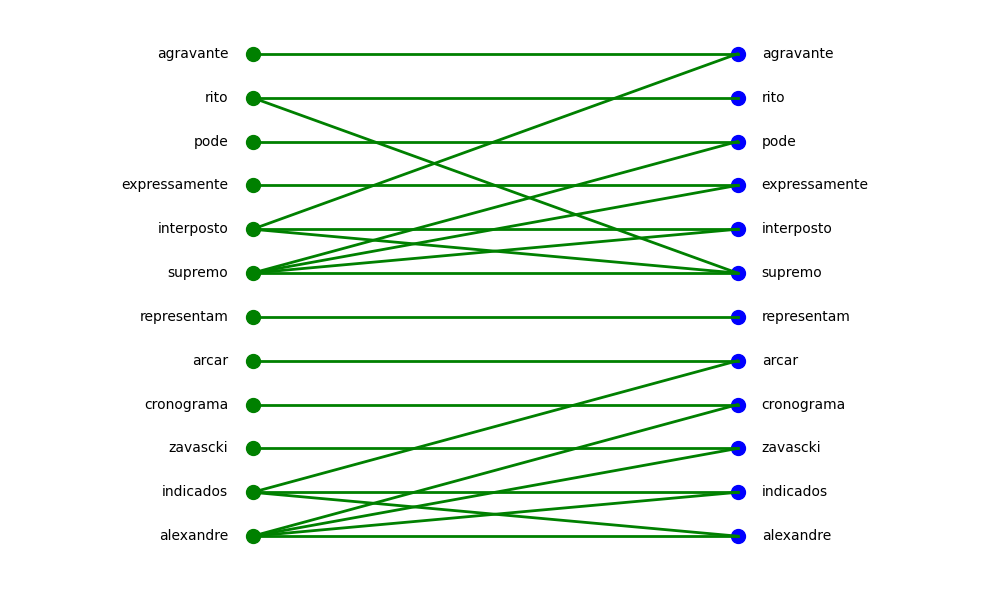

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import random

#words_sorted = random.sample(text.split(" "), 2)
words_sorted = ["alexandre", "supremo"]
num_similars = 6

compare_words = {
    word: [(i,w)  for i,w,_, in model3.similarity_cosine(word, num_similars)]
    for word in words_sorted
}

words_left = []
for word in compare_words.keys():
    for i, _ in compare_words[word]:
        words_left.append(i)

words_left = list(enumerate(dict.fromkeys(words_left)))
words_right = words_left

similars = {}

for i in range(len(words_left)):
    word = words_left[i][1]
    similar = model3.similarity_cosine(word, 4)

    for w, s, _ in similar:
        if word not in similars:
            similars[word] = {
                "source": i,
                "target": []
            }

        if w in [item[1] for item in words_left]:
            w_index = next(idx for idx, val in words_left if val == w)
            similars[word]["target"].append((w_index, s))

list_ = list(enumerate(dict.fromkeys(similars)))
connections = []
for word in list_:
    for target, w in similars[word[1]]["target"]:
        connections.append([
            similars[word[1]]["source"],
            target,
            round(w, 1)
        ])

y_left = np.arange(len(words_left))
y_right = np.arange(len(words_right))

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter([0] * len(y_left), y_left, c="green", s=100, label="Left Words")
ax.scatter([1] * len(y_right), y_right, c="blue", s=100, label="Right Words")

for i, word in words_left:
    ax.text(-0.05, y_left[i], word, ha="right", va="center", fontsize=10)

for i, word in words_right:
    ax.text(1.05, y_right[i], word, ha="left", va="center", fontsize=10)

for left, right, weight in connections:
    ax.plot([0, 1], [y_left[left], y_right[right]], "green", alpha=weight, linewidth=2)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-1, max(len(words_left), len(words_right)))
ax.axis("off")

plt.tight_layout()
plt.show()

[('alexandre', 0.99999994), ('indicados', 0.9999902), ('zavascki', 0.99998933), ('cronograma', 0.9999875), ('arcar', 0.99998677), ('representam', 0.99998665), ('ncpc', 0.9999861), ('verbas', 0.9999855), ('funcao', 0.99998546), ('conheceram', 0.9999854)]


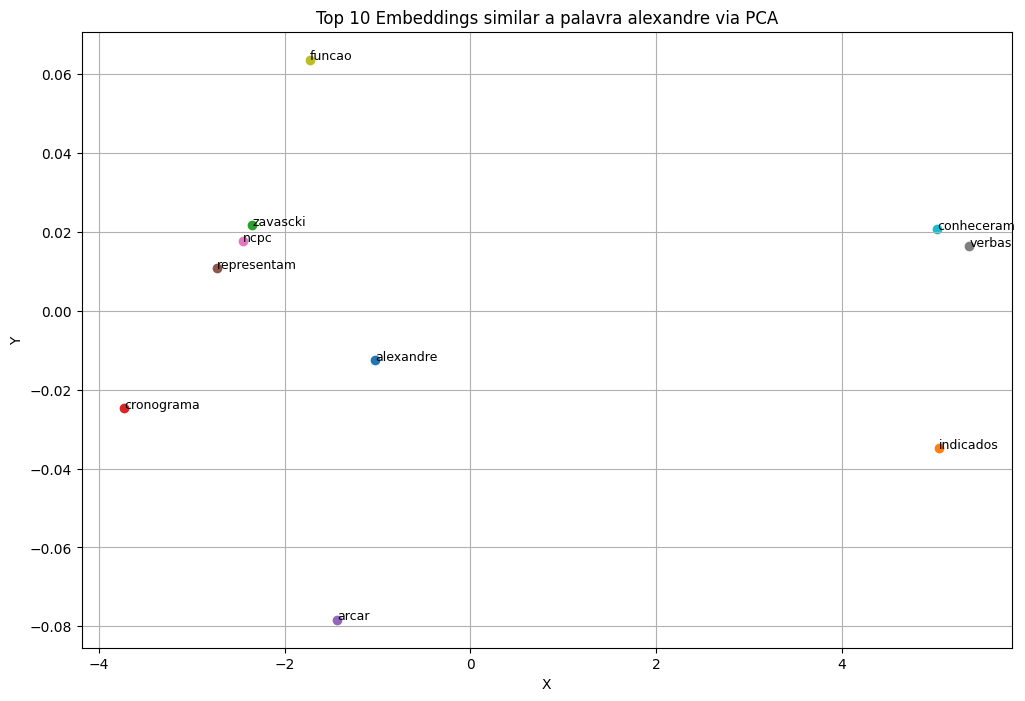

In [ ]:
word = "alexandre"
length = 10
print([(x, y) for x, y,_ in model3.similarity_cosine(word, length)])
model3.plot(word, length)

[('juiz', 1.0), ('julgamento', 0.999999), ('precedentes', 0.9999989), ('pessoas', 0.9999989), ('presente', 0.99999887), ('sumula', 0.9999988), ('custas', 0.9999988), ('vigor', 0.9999986), ('apenas', 0.9999986), ('claro', 0.9999986)]


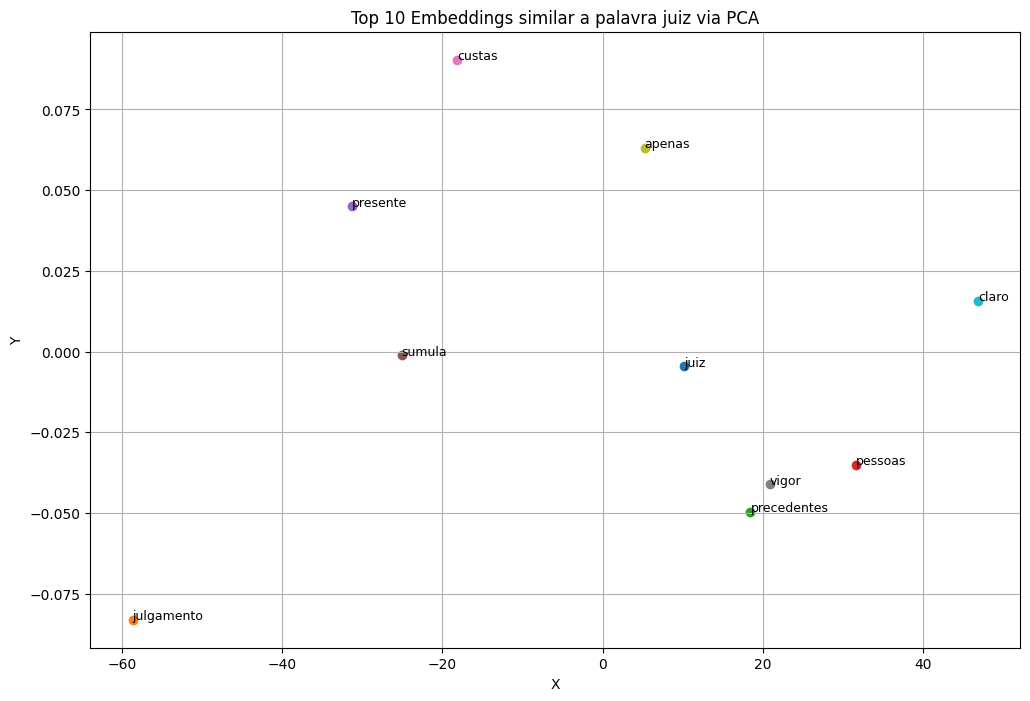

In [ ]:
word = "supremo"
length = 10
print([(x, y) for x, y,_ in model3.similarity_cosine(word, length)])
model3.plot(word, length)